In [ ]:

import polars as pl
import pandas as pd
import re
import numpy as np
pl.Config.set_tbl_rows(20)

In [3]:
pl_df = pl.read_csv("merged_dedup.csv")

In [6]:
#convert the EID TO DOI so its easier to check
#edges_pl=pl.read_csv("edges_scopus_all.csv")

In [ ]:
references_df = pd.read_parquet('ref_final.parquet')

In [8]:
# Load only the 'EID' and 'DOI' columns from merged_dedup.csv
#merged_df = pl.read_csv("Scopus_merged.csv", columns=["EID", "DOI"])
# Create mapping dictionary (EID -> DOI)
#eid_to_doi = dict(zip(merged_df["EID"], merged_df["DOI"]))
edges_pl=edges_pl.with_columns(
    EID=pl.col("EID").replace_strict(eid_to_doi)
)
edges_pl.write_csv("correctec_EID.csv")

In [ ]:
import cugraph
import cudf
import pandas as dd
import json

# Load and rename edges
edges = cudf.read_csv("edges_scopus_citation.csv")
filtered_edges = edges[edges['Citation_Count'].notnull()]
edges_df = cudf.DataFrame(filtered_edges)
edges_df = edges_df.rename(columns={'DOI': 'source', 'EID': 'destination'})

# Convert edges_df to Pandas for easier node selection
edges_dd = edges_df_dd

# Get a unique list of nodes from source and destination columns
all_nodes = dd.concat([edges_dd['source'], edges_dd['destination']]).unique()

# Limit nodes to the first 100
num_nodes_to_keep = 100
top_node_ids = all_nodes[:num_nodes_to_keep].tolist()

# Create nodes JSON
nodes = [{'data': {'id': str(node)}} for node in top_node_ids]

# Create edges JSON (without filtering)
edges = [{'data': {'source': str(row['source']), 'target': str(row['destination'])}} for _, row in edges_dd.iterrows()]

# Create Cytoscape.js data
cytoscape_data = {'nodes': nodes, 'edges': edges}

# Convert to JSON and write to file
json_data = json.dumps(cytoscape_data)
with open('cytoscape_graph.json', 'w') as f:
    json.dump(cytoscape_data, f)

In [ ]:
import polars as pl
import os
import time
import psutil  # For optional memory monitoring

# Define folder path
folder = "../../data/references/scopus_citations"
output_arrow_file = "../../data/references/processed/scopus_citations_chunked.arrow"
concat_chunk_size = 1000  # Concatenate every 1000 files (adjust as needed)

all_dataframes = []
processed_count = 0
total_files = sum(1 for f in os.listdir(folder) if f.endswith(".csv"))
overall_start_time = time.time()

print(f"Total CSV files to process: {total_files}")

for i, f in enumerate(os.listdir(folder)):
    if f.endswith(".csv"):
        filepath = os.path.join(folder, f)
        try:
            print(f"Reading file: {f} ({i+1}/{total_files})")
            start_time = time.time()
            df_temp = pl.read_csv(filepath, schema_overrides={"Citation_Count": pl.Utf8})
            end_time = time.time()
            read_time = end_time - start_time
            print(f"  Read time: {read_time:.4f} seconds")

            # Explicitly cast Citation_Count to String immediately after reading
            df_temp = df_temp.with_columns(pl.col("Citation_Count").cast(pl.Utf8))

            # Convert Citation_Count to integer, handling potential errors
            df_temp = df_temp.with_columns(
                pl.col("Citation_Count")
                .fill_null("0")  # Replace null/missing values with "0"
                .str.replace("", "0") # Still useful for potential empty strings within content
                .cast(pl.Int32, strict=False)
                .alias("Citation_Count_int")
            ).drop("Citation_Count").rename({"Citation_Count_int": "Citation_Count"})

            all_dataframes.append(df_temp)
            processed_count += 1

            if processed_count % concat_chunk_size == 0 or processed_count == total_files:
                if all_dataframes:
                    print(f"Concatenating {len(all_dataframes)} DataFrames (batch {processed_count // concat_chunk_size + (1 if processed_count % concat_chunk_size != 0 else 0)})...")

                    # Print schemas before concatenation for the final batch
                    if processed_count == total_files:
                        for idx, df in enumerate(all_dataframes):
                            print(f"Schema of DataFrame {idx + 1} before final concatenation:")
                            print(df.schema)

                    start_concat_time = time.time()
                    df_chunk = pl.concat(all_dataframes)
                    end_concat_time = time.time()
                    concat_time = end_concat_time - start_concat_time
                    print(f"  Concatenation time: {concat_time:.4f} seconds")

                    # Append the chunk to the Arrow file
                    mode = "wb" if i < concat_chunk_size else "ab"  # 'wb' for first batch
                    with open(output_arrow_file, mode) as outfile:
                        df_chunk.write_ipc(outfile)
                    print(f"  Batch saved/appended to: {output_arrow_file}")

                    all_dataframes = []  # Clear the list for the next batch

        except Exception as e:
            print(f"Error reading file '{f}': {e}")

overall_end_time = time.time()
total_processing_time = overall_end_time - overall_start_time

if not total_files:
    print("No valid CSV files were found.")
elif total_files > 0 and processed_count == total_files:
    print(f"\nAll {total_files} CSV files processed and saved to: {output_arrow_file}")
    print(f"Total processing time: {total_processing_time:.2f} seconds")
elif processed_count < total_files:
    print(f"\nProcessed {processed_count} out of {total_files} CSV files.")
    print(f"Total processing time so far: {total_processing_time:.2f} seconds")  # Handle empty files

In [ ]:
import pyarrow.ipc as ipc

with open("../../data/references/processed/scopus_citations_chunked.arrow", "rb") as f:
    reader = ipc.RecordBatchFileReader(f)
    table = reader.read_all()
    
    
    print(table.slice(0, 5).to_pandas())


In [ ]:
pl_df=pl.from_pandas(pl_df)

In [ ]:
import polars as pl
import pyarrow.ipc as ipc

with open("../../data/references/processed/scopus_citations_chunked.arrow", "rb") as f:
    reader = ipc.RecordBatchFileReader(f)
    table = reader.read_all()
    
    df = pl.from_arrow(table)
df.columns



In [ ]:
# Assuming df is your current dataframe and other_df is the dataframe with EID and title mapping
# Join the dataframes on the EID column
pl_df_pl = pl.DataFrame(pl_df)
result = df.join(
    pl_df_pl.select(["EID", "Title"]).rename({"Title": "EID_Title"}),
    on="EID",
    how="left"
)

# Now you can either keep both columns or replace the EID column with the title
# To replace EID with the title:

result = result.with_columns(
    pl.col("EID_Title").alias("EID")
).drop("EID_Title")

In [ ]:
scopus=dd.read_parquet("../../data/references/processed/scopus_references_with_input.parquet")

In [ ]:

pubmed=dd.read_parquet("../../data/references/processed/Pubmed_refs_corrected.parquet")
import pandas as pd

# Assuming your DataFrame is named references_df and has 'title' and 'year' columns

def can_be_int(value):
    """Checks if a value can be converted to an integer."""
    try:
        int(value)
        return True
    except (ValueError, TypeError):
        return False

def swap_title_with_year_if_title_is_int(row):
    """
    Checks if the 'title' in a row can be converted to an integer.
    If it can, it swaps the values of the 'title' and 'year' columns.
    """
    if can_be_int(row['title']):
        title_val = row['title']
        year_val = row['year']
        row['title'] = year_val
        row['year'] = title_val
    return row

pubmed = pubmed.apply(swap_title_with_year_if_title_is_int, axis=1)
pubmed.to_parquet("../../data/references/processed/Pubmed_refs_corrected.parquet")
print(references_df[['destination', 'year']].head())


In [ ]:
import pandas as pd
iee=pd.read_parquet("../../data/references/processed/ieee_refs_and_cites_fix.parquet")
iee_renamed = iee.rename(columns={'source_doi': 'source_doi',
                                       'source_title': 'source', 
                                       'authors': 'authors', 
                                       'title': 'destination', 
                                       'journal':'journal',
                                       'details': 'details',
                                       'type': 'type',
                                       'html': 'html',
                                       'parsing_status': 'parsing_status'})
del iee

scopus=pd.read_parquet("../../data/references/processed/scopus_references_with_input.parquet")
scopus_renamed = scopus.rename(columns={
    "Authors": 'authors', # Renamed to 'authors'
    "Title": 'destination', # Assuming 'Title' in Scopus is the cited article's title
    "Year": 'year',
    "Source title": 'journal', # Assuming 'Source title' in Scopus is the journal of the cited article
    "Volume": 'volume', # Standardizing these if you want to keep them
    "Issue": 'issue',   # Standardizing these if you want to keep them
    "Page start": 'page_start', # Using snake_case for consistency
    "Page end": 'page_end',     # Using snake_case for consistency
    "DOI": 'doi',
    "Cited by": 'cited_by', # Renamed to 'cited_by'
    "Article Number": 'article_number', # Keep if relevant, or drop
    "Input_Authors": 'source_authors', # Keeping it, distinct from 'authors'
    "Input_Title": 'source',         # 'source' title for the citing article
    "Input_Year": 'source_year',     # 'source_year' for the citing article's year
    "EID": 'eid'                     # Scopus specific identifier
})
del scopus


pubmed=pd.read_parquet("../../data/references/processed/Pubmed_refs_corrected.parquet")
pubmed_renamed = pubmed.rename(columns={'PMID': 'PMID',
                                       'source_title': 'source',
                                       'souce_full_names': 's_authors',
                                       'authors': 'authors', # Example of handling different details
                                       'title': 'destination',
                                       'year': 'year',
                                       'journal': 'journal',
                                       'details': 'details',
                                       'doi': 'doi',
                                       'type': 'type',
                                       'html': 'html',
                                       'parsing_status': 'parsing_status'})
del pubmed


In [ ]:
import pandas as pd

# Assuming your DataFrame is named references_df and has 'title' and 'year' columns

def can_be_int(value):
    """Checks if a value can be converted to an integer."""
    try:
        int(value)
        return True
    except (ValueError, TypeError):
        return False

def swap_title_with_year_if_title_is_int(row):
    """
    Checks if the 'title' in a row can be converted to an integer.
    If it can, it swaps the values of the 'title' and 'year' columns.
    """
    if can_be_int(row['title']):
        title_val = row['title']
        year_val = row['year']
        row['title'] = year_val
        row['year'] = title_val
    return row

pubmed = pubmed.apply(swap_title_with_year_if_title_is_int, axis=1)
pubmed.to_parquet("../../data/references/processed/Pubmed_refs_corrected.parquet")
print(references_df[['destination', 'year']].head())

In [ ]:
len(iee_renamed['source'].unique())

In [ ]:
len(scopus_renamed['source'].unique())

In [ ]:
len(pubmed_renamed['source'].unique())

In [ ]:
len(iee_renamed['source'].unique())+ len(scopus_renamed['source'].unique()) + len(pubmed_renamed['source'].unique())

In [ ]:
scopus_sources = scopus_renamed['source'].unique()

# Filter PubMed to exclude sources already in Scopus
pubmed_filtered = pubmed_renamed[~pubmed_renamed['source'].isin(scopus_sources)]

# Concatenate IEEE, Scopus, and filtered PubMed
references_df = pd.concat([iee_renamed, scopus_renamed, pubmed_filtered], ignore_index=True)

del iee_renamed
del scopus_renamed
del pubmed_renamed

In [ ]:
len(references_df['source'].unique())

In [ ]:
references_df

In [11]:
import pandas as pd
import re
import numpy as np

def extract_destination_from_failed_html(html_string):
    """
    Extracts text between <em> and </em> tags from an HTML string.
    Returns the extracted text or None if not found.  Changed to None.
    """
    if isinstance(html_string, str):
        match = re.search(r'<em>(.*?)<\/em>', html_string)
        match2 =re.search(r'"">(.\w.*?)<\/div>',html_string)
        if match:
            return match.group(1)
        if match2:
            return match2.group(1)
    return None  # Changed to None

# Filter the DataFrame for rows where 'parsing_status' is "failed"
failed_df = references_df[references_df['parsing_status'] == "failed"].copy()

# Apply the function to the 'html' column of the filtered DataFrame
failed_df['destination_extracted'] = failed_df['html'].apply(extract_destination_from_failed_html)

# Identify rows where extraction was successful (not None)
mask = failed_df['destination_extracted'].notna()

# Update the original DataFrame using .loc
references_df.loc[failed_df.index[mask], 'destination'] = failed_df.loc[failed_df.index[mask], 'destination_extracted']
references_df.loc[failed_df.index[mask], 'details'] = 'probably a tool'
references_df.loc[failed_df.index[mask], 'parsing_status'] = 'fixed'  # Update parsing_status

# Remove the temporary 'destination_extracted' column
references_df.drop(columns=['destination_extracted'], inplace=True, errors='ignore') #Added errors ignore

# Print some of the updated rows to verify
print(references_df[references_df['parsing_status'] == "fixed"][['html', 'destination', 'details', 'parsing_status']].head()) #changed to fixed


                                                   html  \
450   <div _ngcontent-ng-c3884093277="">http: //star...   
1488  <div _ngcontent-ng-c3884093277=""><em>Dataset ...   
1490  <div _ngcontent-ng-c3884093277=""><em>Clean_ra...   
1491  <div _ngcontent-ng-c3884093277=""><em>Introduc...   
2420  <div _ngcontent-ng-c3884093277="">"EEG Leads. ...   

                                            destination          details  \
450                 http: //starlab. es/products/enobio  probably a tool   
1488                 Dataset automatic artifact removal  probably a tool   
1490                              Clean_rawdata plug-in  probably a tool   
1491  Introducing the actiCHamp Plus - offering acti...  probably a tool   
2420         "EEG Leads. International 10–20 standard".  probably a tool   

     parsing_status  
450           fixed  
1488          fixed  
1490          fixed  
1491          fixed  
2420          fixed  


In [12]:


def extract_fields_from_failed_html(html_string):
    """
    Extracts author, year, destination, journal, and details from an HTML string
    using a regular expression. Returns a dictionary with the extracted values
    or None for each if not found.
    """
    if isinstance(html_string, str):
        match = re.search(r'^(.*?) \((\d{4})\): (.*?)\. (.*?):(.*?)\.', html_string)
        if match:
            return {
                "authors": match.group(1),
                "year": int(match.group(2)),  # Convert year to integer
                "destination": match.group(3),
                "journal": match.group(4),
                "details": match.group(5),
            }
    return {
        "authors": None,
        "year": None,
        "destination": None,
        "journal": None,
        "details": None,
    }


# Filter the DataFrame for rows where 'parsing_status' is "failed"
failed_df = references_df[references_df['parsing_status'] == "failed"].copy()

# Apply the function to the 'html' column of the filtered DataFrame
failed_df['extracted_data'] = failed_df['html'].apply(extract_fields_from_failed_html)

# Create a mask for successful extractions (where at least one value is not None)
mask = failed_df['extracted_data'].notna()

# Update the original DataFrame using .loc and the mask
for field in ['authors', 'year', 'destination', 'journal', 'details']:
    references_df.loc[failed_df.index[mask], field] = references_df.loc[
        failed_df.index[mask], field
    ].combine(
        failed_df.loc[failed_df.index[mask], 'extracted_data'].apply(lambda x: x[field] if x else None),
        lambda x1, x2: x2 if pd.notnull(x2) else x1,
    )

references_df.loc[failed_df.index[mask], 'parsing_status'] = 'fixed'

# Remove the temporary 'extracted_data' column
references_df.drop(columns=['extracted_data'], inplace=True, errors='ignore')

# Print some of the updated rows to verify
print(
    references_df[references_df['parsing_status'] == "fixed"][
        ['html', 'authors', 'year', 'destination', 'journal', 'details', 'parsing_status']
    ].head()
)


                                                   html authors  year  \
450   <div _ngcontent-ng-c3884093277="">http: //star...    None  None   
1128  <div _ngcontent-ng-c3884093277="">            ...    None   NaN   
1488  <div _ngcontent-ng-c3884093277=""><em>Dataset ...    None  None   
1490  <div _ngcontent-ng-c3884093277=""><em>Clean_ra...    None  None   
1491  <div _ngcontent-ng-c3884093277=""><em>Introduc...    None  None   

                                            destination journal  \
450                 http: //starlab. es/products/enobio    None   
1128                                               none    None   
1488                 Dataset automatic artifact removal    None   
1490                              Clean_rawdata plug-in    None   
1491  Introducing the actiCHamp Plus - offering acti...    None   

              details parsing_status  
450   probably a tool          fixed  
1128             None          fixed  
1488  probably a tool          fixed  
14

In [13]:
import pandas as pd

def process_authors_column(df):
    """
    Processes the 'authors' column of a Pandas DataFrame.

    For each row, if the 'authors' value is a string that can be split
    by commas, it replaces the string with a list of stripped author names.
    If any of those names themselves contain a comma, they are further
    split to separate surname from given names.

    Args:
        df: The Pandas DataFrame to process.

    Returns:
        The modified Pandas DataFrame.
    """
    def split_authors(authors_value):
        """
        Helper function to split and strip author names, and handle
        surname-given name separation.
        """
        if isinstance(authors_value, str):
            authors_list = authors_value.split(',')
            processed_authors = []
            for author in authors_list:
                author = author.strip()
                if ',' in author:
                    surname_given = author.split(',')
                    processed_authors.extend([s.strip() for s in surname_given])
                else:
                    processed_authors.append(author)
            return processed_authors
        return authors_value

    df['authors'] = df['authors'].apply(split_authors)
    return df

# Apply the function to references_df
references_df = process_authors_column(references_df)



In [ ]:
#references_df["year"] = pd.to_numeric(references_df["year"], errors="coerce")

#references_df.to_parquet('../../data/references/processed/ref_final.parquet')
references_df['source'] = references_df['source'].astype(str).str.strip().str.rstrip('.').str.lower()
references_df['destination'] = references_df['destination'].astype(str).str.strip().str.rstrip('.').str.lower()
references_df['year'] = references_df['year'].astype(str)
references_df['source_authors '] = references_df['source_authors'].astype(str)
# Now, use .apply() to replace the string 'None' with a proper empty list `[]`
references_df['source_authors'] = references_df['source_authors'].apply(lambda x: [] if x == 'None' or x==None else x)

references_df.to_parquet('data/references/processed/ref_final.parquet')

In [24]:
references_df=pd.read_parquet('ref_1_final.parquet')

In [18]:
references_df['year'] = references_df['year'].astype(str)
references_df.to_parquet('ref_1_final.parquet')

In [25]:
references_df

,source_doi,source,authors,destination,journal,details,type,html,parsing_status,year,...,page_start,page_end,doi,cited_by,article_number,source_authors,source_year,eid,PMID,s_authors
0,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[R. R. Vazquez, H. V. Perez, R. Ranta, V. L. D...",blind source separation wavelet denoising and ...,Biomedical Signal Processing and Control,"vol. 7, pp. 389-400, 2012.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
1,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[X. Chen, A. Liu, Q. Chen, Y. Liu, L. Zou and ...",simultaneous ocular and muscle artifact remova...,Computers in Biology and Medicine,"vol. 88, pp. 1-10, 2017.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
2,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[R. Upadhyay, P.K. Padhy and P.K. Kankar]",ocular artifacts removal from eeg signals usin...,2015 Annual IEEE India Conference (INDICON),"pp. 1-5, 2015.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
3,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[B.W. Jervis, M. Coelho and G.W. Morgan]",effect on eeg response of removing ocular arti...,Med Bio Eng Comput,"vol. 27, pp. 484-490, 1989.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
4,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,[R.J. Croft and R.J. Barry],removal of ocular artifacts from eeg: a review,Clin Neurophysiol,"vol. 30, pp. 5-19, 2000.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250394,None,a framework for the design of flexible cross-t...,"[Schoffelen JM, Gross J]",Source connectivity analysis with MEG and EEG,Hum Brain Mapp 30,1857–1865,reference,"Schoffelen JM, Gross J (2009): Source connecti...",fixed,2009.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250395,None,a framework for the design of flexible cross-t...,"[Sekihara K, Sahani M, Nagarajan SS]",Localization bias and spatial resolution of ad...,Neuroimage 25,1056–1067,reference,"Sekihara K, Sahani M, Nagarajan SS (2005): Loc...",fixed,2005.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250396,None,a framework for the design of flexible cross-t...,"[Taulu S, Simola J]",Spatiotemporal signal space separation method ...,Phys Med Biol 51,1759–1768,reference,"Taulu S, Simola J (2006): Spatiotemporal signa...",fixed,2006.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250397,None,a framework for the design of flexible cross-t...,"[Van Veen BD, van Drongelen W, Yuchtman M, Suz...",Localization of brain electrical activity via ...,IEEE Trans Biomed Eng 44,867–880,reference,"Van Veen BD, van Drongelen W, Yuchtman M, Suzu...",fixed,1997.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"


# Analasis co citation 

In [19]:
import pandas as pd
import polars as pl
import numpy as np
import scipy.sparse as sp
#references_df= pd.read_parquet('../../data/references/processed/ref_final.parquet')
import os 
#cwd = os.getcwd()
#print(cwd)

#references_df= pd.read_parquet('../references/processed/ref_final.parquet')
references_df= pd.read_parquet('ref_final.parquet')
    
# Convert 'source_year' to numeric (handle errors if needed)
references_df['source_year'] = pd.to_numeric(references_df['source_year'], errors='coerce')

# Drop rows with invalid years (optional)
#references_df = references_df.dropna(subset=['source_year'])


In [27]:
references_df_exploded = references_df.explode('destination')
references_df_exploded

,source_doi,source,authors,destination,journal,details,type,html,parsing_status,year,...,page_start,page_end,doi,cited_by,article_number,source_authors,source_year,eid,PMID,s_authors
0,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[R. R. Vazquez, H. V. Perez, R. Ranta, V. L. D...",blind source separation wavelet denoising and ...,Biomedical Signal Processing and Control,"vol. 7, pp. 389-400, 2012.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
1,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[X. Chen, A. Liu, Q. Chen, Y. Liu, L. Zou and ...",simultaneous ocular and muscle artifact remova...,Computers in Biology and Medicine,"vol. 88, pp. 1-10, 2017.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
2,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[R. Upadhyay, P.K. Padhy and P.K. Kankar]",ocular artifacts removal from eeg signals usin...,2015 Annual IEEE India Conference (INDICON),"pp. 1-5, 2015.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
3,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,"[B.W. Jervis, M. Coelho and G.W. Morgan]",effect on eeg response of removing ocular arti...,Med Bio Eng Comput,"vol. 27, pp. 484-490, 1989.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
4,10.1109/ICUMT.2018.8631219,eeg artifact removal and noise suppression usi...,[R.J. Croft and R.J. Barry],removal of ocular artifacts from eeg: a review,Clin Neurophysiol,"vol. 30, pp. 5-19, 2000.",reference,None,None,None,...,None,None,None,NaN,None,None,NaN,None,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1250394,None,a framework for the design of flexible cross-t...,"[Schoffelen JM, Gross J]",Source connectivity analysis with MEG and EEG,Hum Brain Mapp 30,1857–1865,reference,"Schoffelen JM, Gross J (2009): Source connecti...",fixed,2009.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250395,None,a framework for the design of flexible cross-t...,"[Sekihara K, Sahani M, Nagarajan SS]",Localization bias and spatial resolution of ad...,Neuroimage 25,1056–1067,reference,"Sekihara K, Sahani M, Nagarajan SS (2005): Loc...",fixed,2005.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250396,None,a framework for the design of flexible cross-t...,"[Taulu S, Simola J]",Spatiotemporal signal space separation method ...,Phys Med Biol 51,1759–1768,reference,"Taulu S, Simola J (2006): Spatiotemporal signa...",fixed,2006.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"
1250397,None,a framework for the design of flexible cross-t...,"[Van Veen BD, van Drongelen W, Yuchtman M, Suz...",Localization of brain electrical activity via ...,IEEE Trans Biomed Eng 44,867–880,reference,"Van Veen BD, van Drongelen W, Yuchtman M, Suzu...",fixed,1997.0,...,None,None,None,NaN,None,None,NaN,None,23616402.0,"[Olaf Hauk, Matti Stenroos]"


In [53]:
citation_count_pd = (
    references_df_exploded
    # Group by the unique destination identifier
    .groupby('destination')
    
    # Perform aggregations
    .agg(
        citation_count=('destination', 'size'), # Count the number of rows
        first_non_null_doi=('doi', lambda x: x.iloc[0]) # Get the first associated DOI
    )
    
    # Sort the results by citation count
    .sort_values('citation_count', ascending=False)
).head(21)
citation_count_pd=citation_count_pd[1:]

print(citation_count_pd)

                                                    citation_count  \
destination                                                          
eeglab: an open source toolbox for analysis of ...            3439   
brain-computer interfaces for communication and...            1245   
fieldtrip: open source software for advanced an...            1111   
event-related eeg/meg synchronization and desyn...             968   
eegnet: a compact convolutional neural network ...             942   
deap: a database for emotion analysis; using ph...             877   
deep learning with convolutional neural network...             827   
physiobank, physiotoolkit, and physionet: compo...             808   
removing electroencephalographic artifacts by b...             737   
nonparametric statistical testing of eeg- and m...             732   
optimal spatial filtering of single trial eeg d...             670   
optimizing spatial filters for robust eeg singl...             663   
updating p300: an in

In [73]:
citation_ref=pl.DataFrame({"references":["Delorme2004-os","Wolpaw2002-ac","Oostenveld2011-hg","Lawhern2018-ky","Pfurtscheller1999-wo","Koelstra2012-ke","Goldberger2000-ec","Schirrmeister2017-tl","Maris2007-gl","Ramoser2000-fl","Jung2000-xw","Polich2007-qi","Blankertz2008-gh","Klimesch1999-kk","Ang2008-rk","Brainard1997-vw","Oldfield1971-jm","Lotte2018-mw","Bell1995-lz","Lotte2007-gp"]})
citation_ref=pd.DataFrame({"references":["DM04","Wol+02","Oos+11","Law+18","PL99","Koe+12","Sch+17","Gol+00","Mo07","RMP00","Jun+00","Pol07","Bla+08","Kli99","Ang+08","Bra97","Old71","Lot+18","BS95","Lot+07"]})
citation_count_pd_reset = citation_count_pd.reset_index()
citation = pd.concat([citation_count_pd_reset, citation_ref], axis=1)



In [74]:
citation

,destination,citation_count,first_non_null_doi,references
0,eeglab: an open source toolbox for analysis of...,3439,None,DM04
1,brain-computer interfaces for communication an...,1245,None,Wol+02
2,fieldtrip: open source software for advanced a...,1111,10.1155/2011/156869,Oos+11
3,event-related eeg/meg synchronization and desy...,968,None,Law+18
4,eegnet: a compact convolutional neural network...,942,None,PL99
5,deap: a database for emotion analysis; using p...,877,None,Koe+12
6,deep learning with convolutional neural networ...,827,None,Sch+17
7,"physiobank, physiotoolkit, and physionet: comp...",808,None,Gol+00
8,removing electroencephalographic artifacts by ...,737,None,Mo07
9,nonparametric statistical testing of eeg- and ...,732,10.1016/j.jneumeth.2007.03.024,RMP00


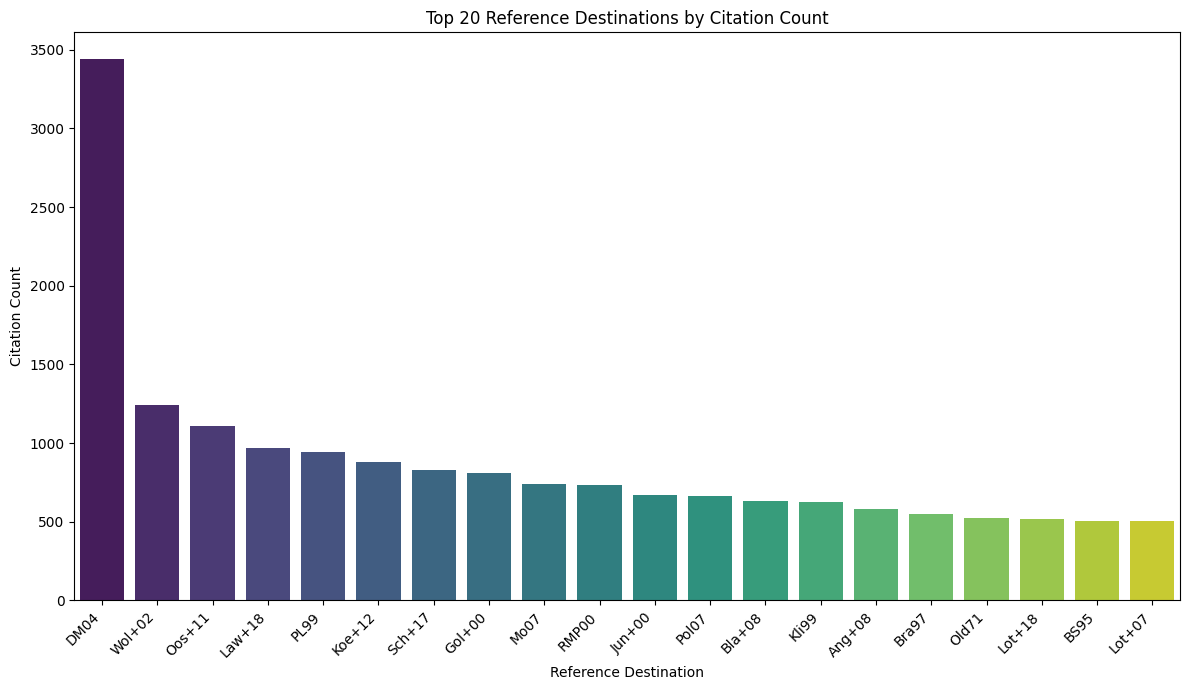

In [77]:
import seaborn as sn
import matplotlib.pyplot as plt
# Create the bar plot
plt.figure(figsize=(12, 7)) # Adjust figure size for better readability
#sn.barplot(data=citation, x="references", y='citation_count', palette='viridis') # Use 'data' argument
sn.barplot(data=citation, x="references", y='citation_count', hue="destination", palette='viridis', legend=False)
# Get the current Axes object
ax = plt.gca()

x_labels = citation['references'].tolist()
# Set the tick locations explicitly (from 0 to N-1, where N is number of bars)
ax.set_xticks(range(len(x_labels)))
# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right') # 'ha' aligns labels correctly after rotation

# Set plot title and labels
plt.title('Top 20 Reference Destinations by Citation Count')
plt.xlabel('Reference Destination')
plt.ylabel('Citation Count')

# Add padding to prevent labels from being cut off
plt.tight_layout()
plt.savefig("Most referenced.pdf")
# Display the plot
plt.show()

In [ ]:
references_df.columns

In [ ]:
def calculate_co_citation(references_df:pd.DataFrame):
    """
    Calculates co-citation counts with authors and publication years for each cited paper.

    Args:
        references_df: A DataFrame with 'source', 'destination', 'authors', and 'year' columns.

    Returns:
        DataFrame with columns: 'cited_1', 'cited_2', 'co_citation_count', 
        'authors_1', 'authors_2', 'year_1', 'year_2'
    """    
    # Validate input
    required_columns = {'source', 'destination', 'authors', 'year'}
    if not isinstance(references_df, pd.DataFrame) or not required_columns.issubset(references_df.columns):
        print("Error: Input must be a Pandas DataFrame with 'source', 'destination', 'authors', and 'year' columns.")
        return pd.DataFrame(columns=['cited_1', 'cited_2', 'co_citation_count','co_citation_year', 
                                   'authors_1', 'authors_2', 'year_1', 'year_2']),""
    
    # Clean and prepare data
    df = references_df[['source', 'destination', 'authors', 'year']].drop_duplicates(subset=['source', 'destination'])
    
    if df.empty:
        return pd.DataFrame(columns=['cited_1', 'cited_2', 'co_citation_count', 'co_citation_year', 
                                    'authors_1', 'authors_2', 'year_1', 'year_2']),""
    # Create mappings for authors and years
    destination_metadata = df.drop_duplicates(subset=['destination']).set_index('destination')
    author_map = destination_metadata['authors']
    year_map = destination_metadata['year']

    # Factorize papers into integer indices
    source_codes, source_uniques = pd.factorize(df['source'])
    dest_codes, dest_uniques = pd.factorize(df['destination'])
    
    # Create sparse citation matrix
    X = sp.coo_matrix(
        (np.ones(len(source_codes), dtype=np.int64), (source_codes, dest_codes)),
        shape=(len(source_uniques), len(dest_uniques))
    ).tocsr()
    
    # Calculate co-citation matrix
    co_citation_matrix = X.T @ (X)
    co_citation_matrix = sp.triu(co_citation_matrix, k=1)  # Remove duplicates and diagonal
    
    # Extract co-citation pairs
    co_citation_coo = co_citation_matrix.tocoo()
    if co_citation_coo.nnz == 0:
        return pd.DataFrame(columns=['cited_1', 'cited_2', 'co_citation_count', 
                                   'authors_1', 'authors_2', 'year_1', 'year_2'])
    
    # Map indices back to paper information
    cited_1 = dest_uniques[co_citation_coo.row]
    cited_2 = dest_uniques[co_citation_coo.col]
    
    return pd.DataFrame({
        'cited_1': cited_1,
        'cited_2': cited_2,
        'co_citation_count': co_citation_coo.data,
        'authors_1': author_map.reindex(cited_1).values,
        'authors_2': author_map.reindex(cited_2).values,
        'year_1': year_map.loc[cited_1].values,
        'year_2': year_map.loc[cited_2].values,
    }), X

# Calculate co-citation results with years
references_df=references_df.dropna(subset=['destination'])
co_citation_results, X = calculate_co_citation(references_df)


In [ ]:
co_citation_results

In [ ]:
print(co_citation_results.describe().to_latex())

In [ ]:
%env NX_CURGAPH_AUTOCONFIG=True
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import cudf # For GPU data handling
import cugraph # For faster graph creation if needed, though NetworkX will be used for LCC
import cupy # For GPU array operations

# --- Load your original references_df here ---
# Example (replace with your actual data loading)
# This `df_original_references` should be your full, unfiltered DataFrame

df_original_references = co_citation_results[['cited_1', 'cited_2', 'co_citation_count', 'year_1', 'year_2']]


# --- Define Cutoff Range ---
# Given your data (max 521, most at 1, some at 6-10 after initial filter),
# test a range that makes sense for your insights.
# You could start from 1, but since you know 1-5 are overwhelming,
# a range like 5 to 100 or 5 to 200 might be more informative.
# Let's test from 1 to 100 with steps, and then a few higher points.
cutoffs = list(range(1, 11, 1)) + list(range(12, 21, 2)) + list(range(25, 101, 5)) + [150, 200, 300, 400, 500]
cutoffs.sort() # Ensure they are in ascending order
print(f"Testing {len(cutoffs)} cutoffs: {cutoffs[:5]} ... {cutoffs[-5:]}")


# --- Store Results ---
results = {
    'cutoff': [],
    'num_edges': [],
    'num_nodes': [],
    'num_components': [],
    'lcc_size': [],
    'lcc_nodes_percentage': []
}

# --- Perform Percolation Analysis ---
for cutoff in cutoffs:
    print(f"\nProcessing cutoff: > {cutoff}")
    # Filter the DataFrame based on the current cutoff
    # Using cuDF for filtering if your original df is large, then converting back for NetworkX.
    # For very large original DFs, doing this on GPU for filtering is critical.
    if isinstance(df_original_references, pd.DataFrame):
        current_df_filtered = df_original_references[df_original_references['co_citation_count'] > cutoff]
    elif isinstance(df_original_references, cudf.DataFrame):
        current_df_filtered = df_original_references[df_original_references['co_citation_count'] > cutoff].to_pandas()
    else:
        raise TypeError("references_df must be a pandas.DataFrame or cudf.DataFrame")

    results['cutoff'].append(cutoff)

    if current_df_filtered.empty:
        print(f"No edges remaining at cutoff > {cutoff}.")
        results['num_edges'].append(0)
        results['num_nodes'].append(0)
        results['num_components'].append(0)
        results['lcc_size'].append(0)
        results['lcc_nodes_percentage'].append(0)
        continue

    # Create an undirected NetworkX graph from the filtered data
    # Ensure to use the correct source/target columns for the edge list
    G_filtered = nx.from_pandas_edgelist(
        current_df_filtered,
        source='cited_1',
        target='cited_2',
        create_using=nx.Graph() # Undirected for connected components
    )

    num_edges = G_filtered.number_of_edges()
    num_nodes = G_filtered.number_of_nodes()

    results['num_edges'].append(num_edges)
    results['num_nodes'].append(num_nodes)

    if num_nodes == 0:
        results['num_components'].append(0)
        results['lcc_size'].append(0)
        results['lcc_nodes_percentage'].append(0)
    else:
        # Calculate connected components (this is CPU-bound in NetworkX)
        connected_components = list(nx.connected_components(G_filtered))
        num_components = len(connected_components)
        lcc_size = max(len(c) for c in connected_components) # Size of largest component

        results['num_components'].append(num_components)
        results['lcc_size'].append(lcc_size)
        results['lcc_nodes_percentage'].append((lcc_size / num_nodes) * 100 if num_nodes > 0 else 0)

    print(f"  Edges: {num_edges}, Nodes: {num_nodes}, Components: {num_components}, LCC Size: {lcc_size}, LCC %: {results['lcc_nodes_percentage'][-1]:.2f}%")


# --- Plotting Results ---
percolation_df = pd.DataFrame(results)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(percolation_df['cutoff'], percolation_df['num_edges'], marker='o', linestyle='-', color='blue', label='Number of Edges')
plt.plot(percolation_df['cutoff'], percolation_df['num_nodes'], marker='x', linestyle='--', color='green', label='Number of Nodes')
plt.title('Network Size vs. Co-citation Cutoff')
plt.xlabel('Co-citation Count Cutoff (exclusive)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(percolation_df['cutoff'], percolation_df['lcc_size'], marker='o', linestyle='-', color='red', label='Size of Largest Connected Component')
plt.plot(percolation_df['cutoff'], percolation_df['lcc_nodes_percentage'], marker='x', linestyle='--', color='purple', label='LCC Size (% of total nodes)')
plt.title('Network Connectivity vs. Co-citation Cutoff')
plt.xlabel('Co-citation Count Cutoff (exclusive)')
plt.ylabel('Size / Percentage')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# Optional: Print the DataFrame for detailed inspection
print("\nPercolation Analysis Results:")
print(percolation_df)

In [ ]:
filtered_df = co_citation_results[co_citation_results['co_citation_count'] > 10]

## %env NX_CURGAPH_AUTOCONFIG=True
import networkx as nx
import holoviews as hv
from holoviews import opts
from holoviews.operation.datashader import datashade, bundle_graph
from holoviews.plotting.bokeh.callbacks import CustomJS
from heapdict import heapdict # Assuming this is used elsewhere, if not, it's not strictly needed here
from heapq import nlargest
import pandas as pd
from bokeh.palettes import Viridis, Plasma, Inferno, Category20 # Import Category20 for node coloring
from bokeh.models import HoverTool
import panel as pn
from bokeh.resources import INLINE

hv.extension('bokeh', 'datashader')

def analyze_co_citation_network(filtered_df, source, target, weight, interactive=True, top_n=10):
    """
    Perform co-citation network analysis with interactive visualization options.

    Args:
        filtered_df: DataFrame with columns ['cited_1', 'cited_2', 'co_citation_count']
        source column string
        target column string
        weight column string
        interactive: If True, uses Bokeh for interactive plot (good for <10k nodes)
                     If False, uses Datashader (better for large networks)
        top_n: Number of top papers to display
    """
    # 1. Network Analysis
    print("\nCreating graph...")
    G_nx = nx.from_pandas_edgelist(
        filtered_df,
        source=source,
        target=target,
        edge_attr=[weight, 'year_1', 'year_2'], # Ensure 'year_1' and 'year_2' are in filtered_df
        create_using=nx.Graph()
    )

    # Calculate metrics
    pagerank = nx.pagerank(G_nx, weight=weight)
    top_papers = nlargest(top_n, pagerank.items(), key=lambda x: x[1])

    # 2. Add attributes directly to the NetworkX graph for seamless HoloViews integration
    # Node Sizing based on PageRank
    nx.set_node_attributes(G_nx, pagerank, 'pagerank')
    
    # Normalize pagerank for sizing
    if pagerank: # Ensure pagerank is not empty
        min_pr = min(pagerank.values())
        max_pr = max(pagerank.values())
        pr_range = max_pr - min_pr if max_pr != min_pr else 1
        
        # Scale node size: larger pagerank -> larger node
        min_size = 5
        max_size = 25
        node_sizes = {
            node: (val - min_pr) / pr_range * (max_size - min_size) + min_size
            for node, val in pagerank.items()
        }
        nx.set_node_attributes(G_nx, node_sizes, 'size')
    else: # Default size if pagerank is empty
        nx.set_node_attributes(G_nx, 10, 'size') # Assign a default size

    # Node Coloring based on Community Detection
    try:
        partition = nx.community.louvain_communities(G_nx, weight=weight)
        num_communities = len(partition)
        
        # Choose palette based on community count
        if num_communities > 20:
            from bokeh.palettes import Turbo256
            palette = Turbo256
            community_colors = {
                node: palette[int((i / num_communities) * 255)]
                for i, comm_set in enumerate(partition)
                for node in comm_set
            }
        else:
            palette = Category20_20 if num_communities > 10 else Set3[max(3, num_communities)]
            community_colors = {
                node: palette[i % len(palette)]
                for i, comm_set in enumerate(partition)
                for node in comm_set
            }
        
        # Store attributes
        nx.set_node_attributes(G_nx, {node: i for i, comm_set in enumerate(partition) for node in comm_set}, 'community')
        nx.set_node_attributes(G_nx, community_colors, 'node_color')

    except ImportError:
        print("Warning: 'python-louvain' not installed. Community detection coloring skipped. Install with: pip install python-louvain")
        nx.set_node_attributes(G_nx, 'grey', 'node_color') # Default if no community detection
    except Exception as e: # Catch other potential errors during community detection
        print(f"Warning: Error during community detection: {e}. Defaulting to grey node color.")
        nx.set_node_attributes(G_nx, 'grey', 'node_color')

    # Edge Weight based on 'weight' attribute for line width
    # Normalize edge width if desired for better visual distinction
    if G_nx.edges: # Ensure edges exist
        max_edge_weight = max(nx.get_edge_attributes(G_nx, weight).values()) if nx.get_edge_attributes(G_nx, weight) else 1
        edge_widths = {
            (u, v): G_nx[u][v][weight] / max_edge_weight * 5 + 0.5
            for u, v in G_nx.edges()
        }
        nx.set_edge_attributes(G_nx, edge_widths, 'line_width')
    else:
        nx.set_edge_attributes(G_nx, 1, 'line_width') # Default if no edges

    # 3. Visualization
    layout_algorithm = nx.spring_layout # Default layout

    colors = ['#000000'] + hv.Cycle('Category20').values # This might not be used if node_color is set explicitly

    if interactive and len(G_nx) < 10000:  # Bokeh for smaller graphs
        print("\nCreating interactive plot (Bokeh)...")

        graph = hv.Graph.from_networkx(G_nx, layout_algorithm).opts(
            title=f"{weight} Network Analysis (Interactive)",
            tools=['hover', 'wheel_zoom', 'pan', 'reset'], # Added reset tool
            width=1920,
            height=1080,
            bgcolor='lightgrey',
            # Node options (referencing attributes added to G_nx)
            node_size='size',
            node_color='node_color',
            node_line_color='black',
            node_line_width=1.5,
            node_alpha=0.8,
            # Edge options (referencing attributes added to G_nx)
            edge_line_width='line_width',
            edge_color='grey',
            edge_alpha=0.6,
            edge_line_dash='solid',
            legend_position='right',
            legend_cols=1,
            
            # Custom hover tools (referencing attributes on the HoloViews elements)
            # Node tooltip
            hover_tooltips=[
                ('Node', '@index'), # 'index' is the default name for the node ID in HoloViews Graph
                ('PageRank', '@pagerank'),
                ('Community', '@community')
            ],

            xaxis=None, # Removes the x-axis entirely
            yaxis=None, # Removes the y-axis entirely            
        )


        #print(graph.nodes.data.head())
        return graph, pagerank

    else:  # Datashader for large graphs
        print("\nCreating datashaded plot...")
        try:
            # First, ensure nodes have 'x' and 'y' coordinates for datashader
            pos = layout_algorithm(G_nx)
            nx.set_node_attributes(G_nx, pos, 'pos')
            
            # Create HoloViews Graph
            hv_graph = hv.Graph.from_networkx(G_nx, nx.get_node_attributes(G_nx, 'pos'))

            # Bundle edges and datashade
            bundled_graph = bundle_graph(hv_graph,
                                         aggregator=ds.count(weight)) # Aggregate by weight count
            
            shaded = datashade(
                bundled_graph,
                cmap=Plasma[256], # Use a perceptually uniform colormap
                line_width=0.5, # Thinner lines for dense graphs
                width=1920,
                height=1080,
                dynamic=False # Set to True for interactive re-rendering on zoom/pan
            ).opts(
                bgcolor='black',
                title=f"{weight} Network Analysis DataShaded",
                xaxis=None, # Removes the x-axis entirely
                yaxis=None, # Removes the y-axis entirely
            )

        except ImportError:
            print("Warning: 'datashader' or required components not installed. Skipping bundled graph.")
            # Fallback for datashader if bundle_graph fails or not installed
            
            # Get node positions
            node_positions = layout_algorithm(G_nx)
            nodes_df = pd.DataFrame.from_dict(node_positions, orient='index', columns=['x', 'y'])
            nodes_df['index'] = nodes_df.index # Add node ID as 'index' for hover/attributes
            nodes_df['pagerank'] = nodes_df['index'].map(pagerank) # Add pagerank
            
            # Create a simple Points element from nodes
            points = hv.Points(nodes_df, kdims=['x', 'y'], vdims=['index', 'pagerank'])
            
            # Create edges DataFrame
            edges_df = nx.to_pandas_edgelist(G_nx, source=source, target=target, edge_attr=[weight])
            
            shaded = datashade(
                points,
                cmap=Plasma[256],
                width=1920,
                height=1080
            ).opts(
                bgcolor='black',
                title=f"{weight} Network Analysis Simple",
                xaxis=None, # Removes the x-axis entirely
                yaxis=None, # Removes the y-axis entirely
            )

        except Exception as e:
            print(f"Warning: Error during datashaded plot creation: {e}. Falling back to basic datashade.")
            # Similar fallback as above if other errors occur
            node_positions = layout_algorithm(G_nx)
            nodes_df = pd.DataFrame.from_dict(node_positions, orient='index', columns=['x', 'y'])
            nodes_df['index'] = nodes_df.index
            nodes_df['pagerank'] = nodes_df['index'].map(pagerank)
            points = hv.Points(nodes_df, kdims=['x', 'y'], vdims=['index', 'pagerank'])
            
            shaded = datashade(
                points,
                cmap=Plasma[256],
                width=1920,
                height=1080
            ).opts(
                bgcolor='black',
                title="Co-citation Network Analysis (Datashaded - Basic Fallback)",
                xaxis=None, # Removes the x-axis entirely
                yaxis=None, # Removes the y-axis entirely
            )
    

        return shaded, pagerank

# Example usage:
interactive_plot, scores = analyze_co_citation_network(filtered_df,'cited_1','cited_2','co_citation_count', interactive=True)

#top_10 = pd.Series(scores).nlargest(100)
#print("Top 20 Papers by PageRank:")
#print(top_10.to_markdown(tablefmt="grid"))  # Pretty-printed table
#pn.pane.HoloViews(interactive_plot).save('co-citation', embed=True, resources=INLINE)
interactive_plot


In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from heapq import nlargest
from matplotlib.colors import to_rgb, to_hex

def draw_labels_without_overlap(G, pos, labels, community_color_map, ax, iterations=50, repulsion=0.003, spring=0.025):
    """
    Draws labels and repositions them iteratively to avoid overlap,
    'locking' labels in place once they are no longer colliding.
    """
    # Create an initial dictionary of label positions, slightly offset from the node
    label_pos = {node: (p[0], p[1] + 0.02) for node, p in pos.items() if node in labels}
    
    # Store the original positions to apply a 'spring' force
    original_pos = label_pos.copy()
    
    # Track which labels need to be moved
    labels_to_move = set(labels.keys())

    for _ in range(iterations):
        if not labels_to_move:
            break
            
        labels_with_collisions = set()
        
        # Check for collisions among the labels that are still being moved
        labels_list = list(labels_to_move)
        for i in range(len(labels_list)):
            node1 = labels_list[i]
            p1 = label_pos[node1]
            
            for j in range(i + 1, len(labels_list)):
                node2 = labels_list[j]
                p2 = label_pos[node2]
                
                # Estimate a simplified bounding box based on label text length
                # A more precise implementation would use renderer.get_window_extent()
                # but this heuristic is effective.
                width1 = 0.05 * len(labels[node1])  # Increased width heuristic
                height1 = 0.02 # Increased height heuristic
                width2 = 0.05 * len(labels[node2]) # Same for consistency
                height2 = 0.02
                
                x_overlap = max(0, min(p1[0] + width1/2, p2[0] + width2/2) - max(p1[0] - width1/2, p2[0] - width2/2))
                y_overlap = max(0, min(p1[1] + height1/2, p2[1] + height2/2) - max(p1[1] - height1/2, p2[1] - height2/2))
                
                if x_overlap > 0 and y_overlap > 0:
                    labels_with_collisions.add(node1)
                    labels_with_collisions.add(node2)
                    
                    # Apply a repulsive force
                    direction = np.array(p1) - np.array(p2)
                    dist = np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)
                    if dist == 0: dist = 1e-6 # Avoid division by zero
                    
                    direction = direction / dist
                    label_pos[node1] = (p1[0] + repulsion * direction[0], p1[1] + repulsion * direction[1])
                    label_pos[node2] = (p2[0] - repulsion * direction[0], p2[1] - repulsion * direction[1])

        # Apply a 'spring' force to pull labels back to their original positions
        for node in labels_to_move:
            p = label_pos[node]
            original_p = original_pos[node]
            direction = np.array(original_p) - np.array(p)
            label_pos[node] = (p[0] + spring * direction[0], p[1] + spring * direction[1])
            
        # Update the set of labels to move for the next iteration
        labels_to_move = labels_with_collisions
        
    # Now, draw the labels at their final, non-overlapping positions
    for node in labels:
        x, y = label_pos[node]
        label_text = labels[node]
        label_color = community_color_map.get(node, '#C0C0C0')
        
        r, g, b = to_rgb(label_color)
        font_color = 'white' if (r*0.299 + g*0.587 + b*0.114) < 0.5 else 'black'
        
        ax.text(
            x, y,
            label_text,
            horizontalalignment='center',
            verticalalignment='bottom',
            fontsize=8,
            color=font_color,
            fontweight='bold',
            bbox=dict(
                boxstyle='round,pad=0.2', 
                facecolor=label_color, 
                edgecolor='none', 
                alpha=0.75
            )
        )

def analyze_co_citation_network(filtered_df, source, target, weight, top_n=3, sparse_factor=1, title="co_citation", ignore=True, use_pagerank=True, pre_pos=None):
    if ignore:
        return

    # --- Build Graph ---
    G_nx = nx.from_pandas_edgelist(
        filtered_df,
        source=source,
        target=target,
        edge_attr=[weight],
        create_using=nx.Graph()
    )

    # --- Compute PageRank or use Degree as a fallback ---
    scores = {}
    if use_pagerank:
        scores = nx.pagerank(G_nx, weight=weight)
        nx.set_node_attributes(G_nx, scores, 'pagerank')
    else:
        scores = dict(G_nx.degree(weight=weight))
        nx.set_node_attributes(G_nx, scores, 'degree')

    # --- Node Sizes ---
    min_score, max_score = min(scores.values()), max(scores.values())
    score_range = max_score - min_score or 1
    node_sizes = {node: (val - min_score)*5 / score_range * 20 + 5 for node, val in scores.items()}
    nx.set_node_attributes(G_nx, node_sizes, 'size')

    # --- Communities ---
    try:
        partition = nx.community.louvain_communities(G_nx, weight=weight)
        nx.set_node_attributes(G_nx, {node: i for i, comm in enumerate(partition) for node in comm}, 'community')
    except Exception:
        nx.set_node_attributes(G_nx, 0, 'community')

    # --- Coloring Logic for Nodes and Edges ---
    num_communities = len(partition)
    num_distinct_colors = min(num_communities, 20)
    community_palette = sns.color_palette("tab20", n_colors=num_distinct_colors)
    sorted_communities = sorted(partition, key=len, reverse=True)
    
    community_color_map = {}
    for i, comm in enumerate(sorted_communities):
        if i < num_distinct_colors:
            color = community_palette[i]
        else:
            color = "#C0C0C0"
        for node in comm:
            community_color_map[node] = to_hex(color)
    node_colors_list = [community_color_map[node] for node in G_nx.nodes()]
    
    edge_colors_list = []
    for u, v in G_nx.edges():
        comm_u = nx.get_node_attributes(G_nx, 'community').get(u)
        comm_v = nx.get_node_attributes(G_nx, 'community').get(v)
        if comm_u == comm_v:
            edge_colors_list.append(community_color_map[u])
        else:
            edge_colors_list.append("#C0C0C0")

    # --- Labels for Top Nodes Per Colored Community ---
    top_nodes = []
    for i in range(min(num_communities, num_distinct_colors)):
        comm = sorted_communities[i]
        community_scores = {node: scores[node] for node in comm}
        top_papers_in_community = nlargest(top_n, community_scores.items(), key=lambda x: x[1])
        top_nodes.extend([node for node, _ in top_papers_in_community])
    
    # --- NEW: Create a dictionary mapping titles to years for labeling
    title_to_year = filtered_df.set_index(source)['year_1'].combine_first(filtered_df.set_index(target)['year_2']).to_dict()

    def get_label_name(node_name, year_map):
        """
        Creates a concise label with the year from a multi-word node name.
        """
        # Return an empty string for any null-like value
        if pd.isna(node_name) or not str(node_name).strip():
            return ""

        STOP_WORDS = {"a", "an", "the", "in", "with", "of", "and", "or", "is","none","for"}
        words = str(node_name).split()
        if words is None:
            return node_name
        meaningful_words = [word for word in words if word.lower() not in STOP_WORDS]
        
        # Get the year and format it as 'YY
        year = year_map.get(node_name)
        year_str = ""
        if year and not pd.isna(year):
            year_str = f" '{int(year) % 100:02d}"
        
        return " ".join(meaningful_words[:2]) + year_str
    
    # --- Layout ---
    if pre_pos:
        pos = pre_pos
    else:
        pos = nx.kamada_kawai_layout(G_nx)
        pos = {node: coord * sparse_factor for node, coord in pos.items()}
    
    # --- Filter out nodes with empty labels
    labels = {node: get_label_name(node, title_to_year) for node in top_nodes}
    labels = {node: label_text for node, label_text in labels.items() if label_text != ""}
    
    # --- Plot ---
    fig, ax = plt.subplots(figsize=(23.38, 16.54), dpi=200)
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
    
    # --- Draw nodes and edges first ---
    nx.draw_networkx_nodes(G_nx, pos,
                            node_color=node_colors_list,
                            node_size=[G_nx.nodes[n]['size'] for n in G_nx.nodes()],
                            edgecolors='black', linewidths=0.5, ax=ax)
    nx.draw_networkx_edges(G_nx, pos,
                            edge_color=edge_colors_list,
                            width=1.5, alpha=0.8, ax=ax)
    
    # --- Add edge labels for coupling counts above a threshold ---
    r="""
    edge_labels = {}
    for u, v, data in G_nx.edges(data=True):
        count = data.get(weight)
        if count is not None and count > 10:  # Adjust threshold as needed
            edge_labels[(u, v)] = str(int(count))
    
    if edge_labels:
        nx.draw_networkx_edge_labels(G_nx, pos, edge_labels=edge_labels, font_size=7, ax=ax)
    """
    # --- Use the new function to draw the labels without overlap ---
    draw_labels_without_overlap(G_nx, pos, labels, community_color_map, ax)
    #draw_one_label_per_zone(G_nx, pos, labels, community_color_map, ax)
    
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_frame_on(False)
    
    plt.savefig(title + ".pdf")
    plt.show()
    
    return fig, scores, pos,labels

In [ ]:
filtered_df.describe()

In [ ]:
filtered_df = co_citation_results[co_citation_results['co_citation_count'] > 10]
interactive_plot, scores_c,c_pos,labels_c = analyze_co_citation_network(filtered_df,'cited_1','cited_2','co_citation_count',ignore=False,title="co citation")


In [ ]:
interactive_plot, scores_c,c_pos,labels_c = analyze_co_citation_network(filtered_df,'cited_1','cited_2','co_citation_count',ignore=False,title="co citation",pre_pos=c_pos)

In [ ]:
labels_c

###### You'll need to add \usepackage{booktabs} and \usepackage{longtable} to your preamble
print(r'\begin{tabular}{rp{10cm}}')
print(r'\toprule')
print(r'Rank & Title & Score \\')
print(r'\midrule')

for i, (title, score) in enumerate(nlargest(20, scores.items(), key=lambda x: x[1]), 1):
    # Escape special characters for LaTeX
    latex_title = title.replace('_', r'\_').replace('&', r'\&').replace('%', r'\%')
    print(f"{i} & {latex_title} & {score:.6f} \\\\")

print(r'\bottomrule')
print(r'\end{tabular}')

### Option 1: Using datashade for density rendering
shaded_graph = datashade(
    interactive_plot,
    cmap=['lightblue', 'darkblue'], # Colormap for density
    line_width=0.5,                  # Line width for rasterized edges
    # You might want to remove node_size/node_color from the datashade call itself
    # as datashade's primary purpose is density, which overrides individual colors
    # You can apply them on the rasterized output if they are still relevant for non-dense elements.
)

# You can then re-apply some aesthetic options if they were lost or to refine the rasterized output
final_display_graph = shaded_graph.opts(
    opts.Graph(
        title=f"Network Analysis (Datashaded)", # Update title to reflect datashading
        tools=['hover', 'wheel_zoom', 'pan', 'reset'], # Re-apply desired tools
        width=1920, height=1080, # Re-apply size
        bgcolor='lightgrey', # Re-apply background
        xaxis=None, yaxis=None, # Re-apply axis removal
        # For rasterized output, `node_size` and `node_color` are typically handled by density.
        # However, if you add specific node rendering after datashading (e.g., small points on top),
        # these options could be relevant.
    )
)
final_display_graph

In [ ]:
#pn.pane.HoloViews(interactive_plot).save(f'co_citation_network', embed=True, resources=INLINE)
type(interactive_plot)

In [ ]:
top_10 = pd.Series(scores).nlargest(100)
pagerank_pd_df = top_10.reset_index()
pagerank_pl_df = pl.from_pandas(pagerank_pd_df)
original_value_col_name = top_10.name if top_10.name is not None else '0' # Pandas default for unnamed Series
pagerank_pl_df = pagerank_pl_df.rename({
    "index": "destination",
    original_value_col_name: "pagerank_score"
})

joined_df = citation.join(
    pagerank_pl_df,
    on="destination",
    how="left"
)
joined_df["destination","references","pagerank_score"]

In [ ]:
latex_column_format = "p{0.65\\linewidth} l r" # Title, Reference (left), PageRank (right)
joined_df_selected_pd=joined_df["destination","references","pagerank_score"].to_pandas()
# Create the Styler object

latex_column_format = "P{0.65\\linewidth} l r" # Changed p to P

# Create the Styler object and apply formatting
styler = joined_df_selected_pd.style \
    .format({
        'pagerank_score': "{:.6f}",
        'references': lambda s: r"\cite{" + s + r"}"
    }) \
    .hide(axis="index")


# Generate the LaTeX string with various options
latex_table_string = styler.to_latex(
    column_format=latex_column_format,
    clines="skip-last;data", # Add horizontal lines only between data rows, not after the last
    caption="Top 20 References by PageRank Score",
    label="tab:top_references_pagerank",
    position="htbp", 
    hrules=True, # Add \toprule, \midrule, \bottomrule (requires booktabs package)
    convert_css=True, # This can convert some CSS styles to LaTeX commands, generally safe
    environment="table",
)
print(latex_table_string)

all_yearly_plots = {}
for i in range(2014,2026):
    co_citation_results, X = calculate_co_citation(references_df[references_df['source_year']==i])
    boolean_mask_for_matching_entries = (
        (co_citation_results['cited_1'].str[:10] == co_citation_results['cited_2'].str[:10]) &
        (co_citation_results['authors_1'] == co_citation_results['authors_2']) &
        (co_citation_results['year_1'] == co_citation_results['year_2'])
    )

    co_citation_results= co_citation_results[~boolean_mask_for_matching_entries]
    filtered_df = co_citation_results[co_citation_results['co_citation_count'] > 20]

    interactive_plot, scores = analyze_co_citation_network(filtered_df,'cited_1','cited_2','co_citation_count', interactive=True)
    pn.pane.HoloViews(interactive_plot).save(f'test_{i}', embed=True, resources=INLINE)
    all_yearly_plots[i] = interactive_plot

import panel as pn
import holoviews as hv
from holoviews import opts
from bokeh.resources import INLINE # Assuming this is correctly imported from your setup

# Make sure you have the HoloViews extension loaded with your desired backend
hv.extension('bokeh') # Or 'plotly'
pn.extension() # Initialize Panel for full interactivity


# Your existing loop to generate and store yearly plots
all_yearly_plots = {}
for i in range(2014, 2026):
    print(f"Processing year: {i}")

    yearly_references_df = references_df[references_df['source_year'] == i].copy()
    if yearly_references_df.empty:
        print(f"No data for source_year {i}. Skipping.")
        continue

    # Pre-process authors column if it contains unhashable types (lists/arrays)
    # This is crucial and should be handled consistently.
    if 'authors' in yearly_references_df.columns and not yearly_references_df['authors'].empty:
        if isinstance(yearly_references_df['authors'].iloc[0], (list, np.ndarray)):
            yearly_references_df['authors'] = yearly_references_df['authors'].apply(
                lambda x: tuple(sorted(x)) if isinstance(x, (list, np.ndarray)) else (x,) if x is not None else np.nan
            )

    co_citation_results, _ = calculate_co_citation(yearly_references_df)

    if co_citation_results.empty:
        print(f"No co-citation results for {i}. Skipping.")
        continue

    boolean_mask_for_matching_entries = (
        (co_citation_results['cited_1'].str[:10].fillna('') == co_citation_results['cited_2'].str[:10].fillna('')) &
        (co_citation_results['authors_1'].astype(str).fillna('') == co_citation_results['authors_2'].astype(str).fillna('')) &
        (co_citation_results['year_1'].fillna(-1) == co_citation_results['year_2'].fillna(-1))
    )

    co_citation_results = co_citation_results[~boolean_mask_for_matching_entries]
    filtered_df = co_citation_results[co_citation_results['co_citation_count'] > 20]

    if filtered_df.empty:
        print(f"No co-citation results after filtering (count > 20) for {i}. Skipping visualization.")
        # If no data, ensure we don't store a 'None' or invalid plot.
        # It's better to store an empty plot or skip the year in the HoloMap
        # if your `analyze_co_citation_network` can't handle empty data elegantly.
        continue # Skip adding to all_yearly_plots if no data for this year.

    # Generate the interactive plot for the current year
    interactive_plot, scores = analyze_co_citation_network(
        filtered_df, 'cited_1', 'cited_2', 'co_citation_count', interactive=True
    )
    
    # Optional: Add a title to each individual plot for clarity in the HoloMap slider
    interactive_plot = interactive_plot.opts(title=f"Co-citation Network: Year {i}")

    # Save the individual plot to HTML (as you're already doing)
    pn.pane.HoloViews(interactive_plot).save(f'test_{i}.html', embed=True, resources=INLINE)

    # Store the HoloViews plot object in the dictionary
    all_yearly_plots[i] = interactive_plot

print("\nFinished generating individual yearly plots and storing them.")

# --- NOW, CREATE AND DISPLAY THE JOINT GRAPH (HoloMap) ---

# Create the HoloMap from the collected plots
# Ensure that all_yearly_plots contains only valid HoloViews objects for the HoloMap
if all_yearly_plots:
    yearly_holomap = hv.HoloMap(all_yearly_plots, kdims=['Year'])

    # Apply global options for consistent styling across all frames in the HoloMap
    # Adjust these options based on the actual elements in your 'interactive_plot' (e.g., Graph, Nodes, Edges)
    yearly_holomap.opts(
        # Example for a hv.Graph element:
        opts.Graph(
            width=900,         # Adjust width
            height=700,        # Adjust height
            tools=['hover'],   # Enable hover tool for interactive inspection
            bgcolor='white',   # Background color
            # Customize nodes and edges if analyze_co_citation_network produces them
            # node_size=hv.dim('degree') * 0.5, # Example if you have a 'degree' vdim on nodes
            # node_color='category_label',    # Example if you have a 'category_label' vdim on nodes
            # edge_line_width='co_citation_count', # Map edge width to co_citation_count
            # edge_color='co_citation_count', # Map edge color to co_citation_count
            # cmap='viridis', # Colormap for edges if colored by count
            # node_labels='index', # If you want to show node names
            # node_label_size=8,
            # edge_labels='co_citation_count', # If you want to show edge weights
            # edge_label_size=6,
            # Normalize edge widths if needed for better visualization across years
            # data_aspect=1, # Maintain aspect ratio
        ),
        # You might also need opts for specific components, e.g., if analyze_co_citation_network
        # returns an Overlay of Nodes and Edges:
        # opts.Nodes(size=10, color='blue', line_width=1),
        # opts.Edges(line_width=hv.dim('co_citation_count')*0.1, color='gray')
    )

    print("\nDisplaying the interactive yearly co-citation graph (HoloMap):")
    # This line will display the interactive widget in your Jupyter output
    yearly_holomap

    # Optional: Save the entire HoloMap as a single HTML file (which includes the player)
    pn.pane.HoloViews(yearly_holomap).save('full_co_citation_animation.html', embed=True, resources=INLINE)
    print("Full interactive animation saved as 'full_co_citation_animation.html'")

else:
    print("No plots were generated for the HoloMap, possibly due to empty data after filtering for all years.")

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp

def calculate_bibliographic_coupling_with_years_and_authors(references_df, start_year=2014, end_year=2024):
    """
    Calculates bibliographic coupling with years and authors information, using the
    correct column for the source paper's year.

    Args:
        references_df: DataFrame with 'source', 'destination', 'source_year', and 'authors' columns
        start_year (int): The start year for filtering source papers.
        end_year (int): The end year for filtering source papers.

    Returns:
        Tuple: (coupling_counts_df, X)
    """
    # Validate input
    required_cols = {'source', 'destination', 'source_year', 'authors'}
    if not required_cols.issubset(references_df.columns):
        missing = required_cols - set(references_df.columns)
        print(f"Error: Missing columns {missing}")
        return None, None

    df = references_df.copy()

    def safe_to_tuple(x):
        if isinstance(x, (np.ndarray, list)):
            return tuple(x)
        elif pd.isna(x):
            return tuple()
        else:
            return (str(x),)

    df['authors'] = df['authors'].apply(safe_to_tuple)

    # --- CORRECTED: Filter sources by the 'source_year' column ---
    df = df[(df['source_year'] >= start_year) & (df['source_year'] <= end_year)]
    
    df = df[['source', 'destination', 'source_year', 'authors']].drop_duplicates()

    # Factorize sources and destinations
    source_codes, source_uniques = pd.factorize(df['source'])
    dest_codes, dest_uniques = pd.factorize(df['destination'])

    # Create metadata mappings for sources
    source_metadata = df.groupby('source').first()
    source_years = source_metadata.loc[source_uniques, 'source_year'].values  # --- CORRECTED: Use 'source_year' ---
    source_authors = source_metadata.loc[source_uniques, 'authors'].values

    # Sparse matrix construction
    X = sp.coo_matrix((np.ones(len(source_codes)), (source_codes, dest_codes)),
        shape=(len(source_uniques), len(dest_uniques)))
    X = X.tocsr()

    # Compute coupling matrix
    coupling_matrix = X.dot(X.T)
    coupling_matrix = sp.triu(coupling_matrix, k=1).tocoo()

    # Create main results dataframe
    coupling_counts = pd.DataFrame({
        'source_1': source_uniques[coupling_matrix.row],
        'source_2': source_uniques[coupling_matrix.col],
        'coupling_count': coupling_matrix.data,
        'authors_1': source_authors[coupling_matrix.row],
        'authors_2': source_authors[coupling_matrix.col],
        'year_1': source_years[coupling_matrix.row],
        'year_2': source_years[coupling_matrix.col]
    })

    return coupling_counts, X
coupling_counts, Y = calculate_bibliographic_coupling_with_years_and_authors(references_df)    

In [ ]:
#co_citation_results, X = calculate_co_citation(references_df[references_df['source_year']==2014])
boolean_mask_for_matching_entries = (
    (coupling_counts['source_1'].str[:10] == coupling_counts['source_2'].str[:10]) &
    (coupling_counts['authors_1'] == coupling_counts['authors_2']) &
    (coupling_counts['year_1'] == coupling_counts['year_2'])
)

coupling_counts= coupling_counts[~boolean_mask_for_matching_entries]

In [ ]:
import pandas as pd
import numpy as np
import scipy.sparse as sp

def calculate_bibliographic_coupling_with_years_and_authors(references_df):
    """
    Calculates bibliographic coupling with years and authors information.

    Args:
        references_df: DataFrame with 'source', 'destination', 'year', and 'authors' columns

    Returns:
        Tuple: (coupling_counts_df, yearly_coupling_df)
    """
    # Validate input
    required_cols = {'source', 'destination', 'year', 'authors'}
    if not required_cols.issubset(references_df.columns):
        missing = required_cols - set(references_df.columns)
        print(f"Error: Missing columns {missing}")
        return None, None

    df = references_df.copy()

    def safe_to_tuple(x):
        # 1. Check if it's already an array or list (e.g., ['author1', 'author2'])
        if isinstance(x, (np.ndarray, list)):
            return tuple(x) # Convert the list/array directly to a tuple
        # 2. Check if it's a scalar NaN/None value (e.g., np.nan, None)
        elif pd.isna(x):
            return tuple() # Return an empty tuple for missing values
        # 3. Otherwise, assume it's a single scalar value (e.g., 'single_author_name')
        else:
            return (str(x),) # Convert to string and wrap in a tuple

    df['authors'] = df['authors'].apply(safe_to_tuple)

    df = df[['source', 'destination', 'year', 'authors']].drop_duplicates()

    # Factorize sources and destinations
    source_codes, source_uniques = pd.factorize(df['source'])
    dest_codes, dest_uniques = pd.factorize(df['destination'])

    # Create metadata mappings for sources
    source_metadata = df.groupby('source').first()
    source_years = source_metadata.loc[source_uniques, 'year'].values
    source_authors = source_metadata.loc[source_uniques, 'authors'].values

    # Sparse matrix construction
    X = sp.coo_matrix((np.ones(len(source_codes)), (source_codes, dest_codes)),
        shape=(len(source_uniques), len(dest_uniques)))
    X = X.tocsr()

    # Compute coupling matrix
    coupling_matrix = X.dot(X.T)
    coupling_matrix = sp.triu(coupling_matrix, k=1).tocoo()

    # Create main results dataframe
    coupling_counts = pd.DataFrame({
        'source_1': source_uniques[coupling_matrix.row],
        'source_2': source_uniques[coupling_matrix.col],
        'coupling_count': coupling_matrix.data,
        'authors_1': source_authors[coupling_matrix.row],
        'authors_2': source_authors[coupling_matrix.col],
        'year_1': source_years[coupling_matrix.row],
        'year_2': source_years[coupling_matrix.col]
    })


    return coupling_counts, X

# Example Usage (assuming references_df is available)
# pl_df = pl.read_csv("merged_dedup.csv")
# references_df = pl_df.to_pandas() # Ensure it's a pandas DataFrame if coming from Polars

coupling_counts, Y = calculate_bibliographic_coupling_with_years_and_authors(references_df)

In [ ]:
%env NX_CURGAPH_AUTOCONFIG=True
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import cudf # For GPU data handling
import cugraph # For faster graph creation if needed, though NetworkX will be used for LCC
import cupy # For GPU array operations

def perform_cutoff_percolation_analysis(
    edge_df,
    source_col,
    target_col,
    weight_col,
    custom_cutoffs=None,
    plot_results=True
):
    """
    Performs a filtering-based percolation (robustness) analysis on a
    network by incrementally increasing a cutoff based on an edge weight column.

    Args:
        edge_df (pd.DataFrame or cudf.DataFrame):
            DataFrame containing the edge list with source, target, and weight columns.
        source_col (str): The name of the column representing the source nodes.
        target_col (str): The name of the column representing the target nodes.
        weight_col (str): The name of the column representing the edge weight
                          (e.g., 'co_citation_count', 'coupling_count').
        custom_cutoffs (list, optional): A sorted list of weight thresholds to test.
            If None, a default range based on the weight distribution is used.
        plot_results (bool): If True, generates and displays the percolation plots.

    Returns:
        pd.DataFrame: A DataFrame containing the percolation metrics for each cutoff.
    """
    # Validate required columns
    required_cols = {source_col, target_col, weight_col}
    if not required_cols.issubset(edge_df.columns):
        missing = required_cols - set(edge_df.columns)
        raise ValueError(f"Input DataFrame is missing required columns: {missing}")

    # Ensure input DataFrame is in pandas format for NetworkX operations and select relevant columns
    if isinstance(edge_df, cudf.DataFrame):
        df_for_analysis = edge_df[[source_col, target_col, weight_col]].to_pandas()
    else:
        df_for_analysis = edge_df[[source_col, target_col, weight_col]]

    # Define Cutoff Range
    if custom_cutoffs is None:
        # Default range, adjustable based on typical weight_col distribution
        min_weight = df_for_analysis[weight_col].min()
        max_weight = df_for_analysis[weight_col].max()

        # Generate a more granular range for lower values and sparser for higher values
        # This helps capture the "phase transition" more effectively.
        cutoffs = []
        if min_weight <= 10:
            cutoffs.extend(range(int(min_weight), min(int(max_weight), 11), 1))
        if max_weight > 10:
            cutoffs.extend(range(12, min(int(max_weight), 21), 2))
        if max_weight > 20:
            cutoffs.extend(range(25, min(int(max_weight), 101), 5))
        if max_weight > 100:
            cutoffs.extend(range(150, min(int(max_weight), 201), 50))
        if max_weight > 200:
            cutoffs.extend(np.linspace(250, max_weight, 5, endpoint=True).astype(int).tolist()) # Add some points up to max_weight

        # Ensure min and max weights are covered if not already
        if min_weight not in cutoffs and min_weight > 0: # Only add if min_weight is a positive threshold
             cutoffs.insert(0, int(min_weight))
        if max_weight not in cutoffs:
            cutoffs.append(int(max_weight)) # Always include the max observed value

        cutoffs = sorted(list(set(cutoffs))) # Remove duplicates and sort
    else:
        cutoffs = sorted(custom_cutoffs) # Use provided custom cutoffs

    # Filter out cutoffs higher than max_weight, or lower than min_weight if sensible
    cutoffs = [c for c in cutoffs if c < df_for_analysis[weight_col].max()]
    if not cutoffs: # If all cutoffs are too high, add a low one to get at least one point
        cutoffs = [int(df_for_analysis[weight_col].min())] # Start from min if no other valid cutoffs

    print(f"Testing {len(cutoffs)} cutoffs: {cutoffs[:5]} ... {cutoffs[-5:] if len(cutoffs) > 5 else cutoffs}")

    # Calculate the total number of unique nodes in the absolute initial graph
    all_initial_nodes = pd.concat([df_for_analysis[source_col], df_for_analysis[target_col]]).unique()
    total_initial_nodes = len(all_initial_nodes)
    print(f"Total unique nodes in the original (unfiltered) network: {total_initial_nodes}")

    # --- Store Results ---
    results = {
        'cutoff': [],
        'num_edges': [],
        'num_nodes_in_filtered_graph': [],
        'num_components': [],
        'lcc_size': [],
        'lcc_nodes_percentage_of_filtered': [],
        'lcc_nodes_percentage_of_total_initial': []
    }

    # --- Perform Percolation Analysis ---
    for cutoff in cutoffs:
        # Filter the DataFrame based on the current cutoff
        current_df_filtered = df_for_analysis[df_for_analysis[weight_col] > cutoff].copy()

        results['cutoff'].append(cutoff)

        if current_df_filtered.empty:
            # If no edges, then all initial nodes are isolated components
            # This accounts for the case where the graph becomes completely fragmented
            results['num_edges'].append(0)
            results['num_nodes_in_filtered_graph'].append(0)
            results['num_components'].append(total_initial_nodes) # All nodes are disconnected
            results['lcc_size'].append(0)
            results['lcc_nodes_percentage_of_filtered'].append(0)
            results['lcc_nodes_percentage_of_total_initial'].append(0)
            continue

        # Create an undirected NetworkX graph from the filtered data
        G_filtered = nx.from_pandas_edgelist(
            current_df_filtered,
            source=source_col, # Use generic source_col
            target=target_col, # Use generic target_col
            create_using=nx.Graph()
        )

        num_edges = G_filtered.number_of_edges()
        num_nodes_in_filtered_graph = G_filtered.number_of_nodes()

        results['num_edges'].append(num_edges)
        results['num_nodes_in_filtered_graph'].append(num_nodes_in_filtered_graph)

        # Calculate connected components
        if num_nodes_in_filtered_graph == 0: # Ensure no error if filtered graph is empty
            num_components = 0
            lcc_size = 0
        else:
            connected_components = list(nx.connected_components(G_filtered))
            num_components = len(connected_components)
            lcc_size = max(len(c) for c in connected_components) if num_components > 0 else 0

        results['num_components'].append(num_components)
        results['lcc_size'].append(lcc_size)

        results['lcc_nodes_percentage_of_filtered'].append(
            (lcc_size / num_nodes_in_filtered_graph) * 100 if num_nodes_in_filtered_graph > 0 else 0
        )
        results['lcc_nodes_percentage_of_total_initial'].append(
            (lcc_size / total_initial_nodes) * 100 if total_initial_nodes > 0 else 0
        )
        
        # Explicitly delete the graph and filtered dataframe to free memory
        del G_filtered
        del current_df_filtered

    percolation_df = pd.DataFrame(results)

    # --- Plotting Results ---
    if plot_results:
        plt.figure(figsize=(18, 7))

        plt.subplot(1, 3, 1)
        plt.plot(percolation_df['cutoff'], percolation_df['num_edges'], marker='o', linestyle='-', color='blue', label='Number of Edges')
        plt.plot(percolation_df['cutoff'], percolation_df['num_nodes_in_filtered_graph'], marker='x', linestyle='--', color='green', label='Nodes in Filtered Graph')
        plt.title(f'Network Size vs. {weight_col} Cutoff')
        plt.xlabel(f'{weight_col} Cutoff (exclusive)')
        plt.ylabel('Count (Log Scale)')
        plt.yscale('log')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        plt.subplot(1, 3, 2)
        plt.plot(percolation_df['cutoff'], percolation_df['num_components'], marker='o', linestyle='-', color='orange', label='Number of Components')
        plt.title(f'Number of Components vs. {weight_col} Cutoff')
        plt.xlabel(f'{weight_col} Cutoff (exclusive)')
        plt.ylabel('Number of Components')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        plt.subplot(1, 3, 3)
        plt.plot(percolation_df['cutoff'], percolation_df['lcc_nodes_percentage_of_filtered'], marker='o', linestyle='-', color='red', label='LCC % (of filtered nodes)')
        plt.plot(percolation_df['cutoff'], percolation_df['lcc_nodes_percentage_of_total_initial'], marker='x', linestyle='--', color='purple', label='LCC % (of total initial nodes)')
        plt.title(f'LCC Size (%) vs. {weight_col} Cutoff')
        plt.xlabel(f'{weight_col} Cutoff (exclusive)')
        plt.ylabel('LCC Size Percentage')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend()

        plt.tight_layout()
        plt.show()

    return percolation_df

# --- Example Usage with co_citation_results ---
# Dummy data for demonstration. In your actual use, `co_citation_results`
# would be the DataFrame containing your co-citation pairs and counts.
if 'co_citation_results' not in locals():
    print("WARNING: Using dummy 'co_citation_results' for demonstration. Please replace with your actual data.")
    dummy_data = {
        'cited_1': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T'],
        'cited_2': ['B', 'C', 'D', 'A', 'F', 'G', 'H', 'E', 'J', 'K', 'L', 'M', 'A', 'P', 'N', 'O', 'S', 'T', 'Q', 'R'],
        'co_citation_count': [500, 450, 300, 80, 70, 60, 50, 40, 30, 25, 20, 15, 12, 10, 8, 7, 6, 5, 4, 3],
        'year_1': [2014, 2014, 2015, 2015, 2016, 2016, 2017, 2017, 2018, 2018, 2019, 2019, 2020, 2021, 2022, 2023, 2015, 2016, 2017, 2018],
        'year_2': [2015, 2016, 2016, 2017, 2017, 2018, 2018, 2019, 2019, 2020, 2020, 2021, 2021, 2022, 2023, 2024, 2016, 2017, 2018, 2019]
    }
    co_citation_results = pd.DataFrame(dummy_data)

# Call the function for co-citation analysis
print("--- Running Percolation Analysis for Co-citation Network ---")
percolation_co_citation_df = perform_cutoff_percolation_analysis(
    edge_df=co_citation_results,
    source_col='cited_1',
    target_col='cited_2',
    weight_col='co_citation_count',
    # custom_cutoffs=[1, 2, 5, 10, 20, 50, 100], # Optional: provide your own cutoffs
    plot_results=True
)
print("\nCo-citation Percolation Results DataFrame:")
print(percolation_co_citation_df)

# --- Example Usage with coupling_counts ---
# Assuming 'coupling_counts_df' is the output from your bibliographic coupling function.
# Here's dummy data if you don't have it defined yet:
if 'coupling_counts' not in locals():
    print("\nWARNING: Using dummy 'coupling_counts_df' for demonstration. Please replace with your actual data.")
    dummy_coupling_data = {
        'source_1': ['P1', 'P1', 'P1', 'P2', 'P2', 'P3', 'P3', 'P4', 'P4', 'P5', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10'],
        'source_2': ['P2', 'P3', 'P4', 'P3', 'P5', 'P4', 'P6', 'P5', 'P7', 'P6', 'P8', 'P9', 'P10', 'P1', 'P2', 'P3'],
        'coupling_count': [500, 450, 300, 480, 250, 400, 200, 350, 150, 30, 10, 8, 7, 6, 5, 4],
        'year_1': [2014]*16, 'year_2': [2015]*16
    }
    coupling_counts_df = pd.DataFrame(dummy_coupling_data)

# Call the function for bibliographic coupling analysis
print("\n--- Running Percolation Analysis for Bibliographic Coupling Network ---")
percolation_coupling_df = perform_cutoff_percolation_analysis(
    edge_df=coupling_counts,
    source_col='source_1', # Generic source column for coupling
    target_col='source_2', # Generic target column for coupling
    weight_col='coupling_count', # Generic weight column for coupling
    # custom_cutoffs=[1, 5, 10, 50, 100, 200, 400], # Optional: provide your own cutoffs
    plot_results=True
)
print("\nBibliographic Coupling Percolation Results DataFrame:")
print(percolation_coupling_df)

In [ ]:
filtered_df_Biblio = coupling_counts[coupling_counts['coupling_count'] > 10]

In [ ]:
print(filtered_df_Biblio.describe().to_latex())

In [ ]:
#I THINK THIS IS IT?
%env NX_CURGAPH_AUTOCONFIG=True
import networkx as nx
import holoviews as hv
from holoviews import opts
from holoviews.operation.datashader import datashade, bundle_graph
from holoviews.plotting.bokeh.callbacks import CustomJS
from heapdict import heapdict # Assuming this is used elsewhere, if not, it's not strictly needed here
from heapq import nlargest
import pandas as pd
from bokeh.palettes import Viridis, Plasma, Inferno, Category20 # Import Category20 for node coloring
from bokeh.models import HoverTool


hv.extension('bokeh', 'datashader')


# Example usage:
filtered_df_Biblio = coupling_counts[coupling_counts['coupling_count'] > 10]
interactive_plot, scores_b,b_pos,labels_b = analyze_co_citation_network(filtered_df_Biblio,'source_1','source_2','coupling_count',title="Biblio",ignore=False,use_pagerank=False)

top_10 = pd.Series(scores).nlargest(10)
print("Top 10 Papers by PageRank:")
print(top_10.to_markdown(tablefmt="grid"))  # Pretty-printed table

#interactive_plot


In [ ]:
interactive_plot, scores_b,b_pos,labels_b = analyze_co_citation_network(filtered_df_Biblio,'source_1','source_2','coupling_count',title="Biblio",ignore=False,use_pagerank=False,pre_pos=b_pos)

In [ ]:
labels_b

In [ ]:
with open("biblioCouplingList.txt", "a") as f:
    # Loop through the keys in alphabetical order
    for key in sorted(scores_b.keys()):
        # Write each key-value pair as a formatted string
        f.write(f"{key}: {scores_b[key]}\n")

In [ ]:
references_df["type"].unique()

In [ ]:
filtered_df_Biblio

In [ ]:
all_yearly_plots = {}
for i in range(2014,2026):
    coupling_counts, Y = calculate_bibliographic_coupling_with_years_and_authors(references_df[references_df['source_year']==i])
    boolean_mask_for_matching_entries = (
        (coupling_counts['source_1'].str[:10] == coupling_counts['source_2'].str[:10]) &
        (coupling_counts['authors_1'] == coupling_counts['authors_2']) &
        (coupling_counts['year_1'] == coupling_counts['year_2'])
    )

    coupling_counts= coupling_counts[~boolean_mask_for_matching_entries]
    filtered_df = coupling_counts[coupling_counts['coupling_count'] > 20]

    interactive_plot, scores = analyze_co_citation_network(filtered_df,'source_1','source_2','coupling_count', interactive=True)
    pn.pane.HoloViews(interactive_plot).save(f'test_{i}', embed=True, resources=INLINE)
    all_yearly_plots[i] = interactive_plot

In [ ]:
import holoviews as hv
import panel as pn
from holoviews import opts

# Initialize HoloViews and Panel (do this once at the top of your notebook/script)
hv.extension('bokeh') # Or 'plotly' if that's what you're using
pn.extension()

# Assume 'all_yearly_plots' dictionary is already populated from your loop:
# all_yearly_plots = {
#     2014: <HoloViews Graph object for 2014>,
#     2015: <HoloViews Graph object for 2015>,
#     ...
#     2025: <HoloViews Graph object for 2025>
# }

# --- Code to display your dictionary of graphs ---

if all_yearly_plots:
    # 1. Create a HoloMap from your dictionary
    # The keys of the dictionary (your years) become the 'Year' dimension
    yearly_holomap = hv.HoloMap(all_yearly_plots, kdims=['Year'])

    # 2. Apply global options for consistent styling across all frames
    # Adjust these options based on how your `analyze_co_citation_network`
    # function constructs the HoloViews Graph (e.g., what vdims are available
    # for line_width, node_size, color etc.)
    yearly_holomap.opts(
        opts.Graph(
            width=900,         # Adjust width for better viewing
            height=700,        # Adjust height
            tools=['hover'],   # Enable hover tool for interactive inspection of nodes/edges
            bgcolor='white',   # Set background color
            # Example styling for edges based on co_citation_count (assuming it's a vdim)
            edge_line_width=hv.dim('co_citation_count') * 0.1, # Scale line width by count
            edge_color=hv.dim('co_citation_count'),       # Color edges by count
            cmap='viridis',    # Colormap for edge colors
            colorbar=True,     # Show a colorbar for edge weights
            
            # Example styling for nodes (adjust if your Graph's nodes have vdims like 'degree')
            # node_size=10,
            # node_color='skyblue',
            # node_labels='index', # Show node names if 'index' is your node ID
            # node_label_size=8,
            
            # Layout customization (optional, if you want a specific static layout)
            # You might need to set layout_provider=StaticLayoutProvider(...)
            # if your analyze_co_citation_network function pre-calculates positions.
            # Otherwise, HoloViews will use a default (often NetworkX spring layout).
            
            title_format="Co-citation Network: {dims[Year].value}" # Dynamic title reflecting the current year
        )
    )

    # 3. Display the HoloMap
    # In a Jupyter Notebook, simply having this as the last line in a cell will render the interactive widget.
    pn.pane.HoloViews(yearly_holomap).save(f'test_bio_full', embed=True, resources=INLINE)
    # Optional: If you want to save this entire interactive HoloMap as a single HTML file:
    # from bokeh.resources import INLINE # Ensure INLINE is imported if used
    # pn.pane.HoloViews(yearly_holomap).save('full_co_citation_animation.html', embed=True, resources=INLINE)
    # print("Full interactive animation saved as 'full_co_citation_animation.html'")

else:
    print("The 'all_yearly_plots' dictionary is empty. No graphs to display.")

In [ ]:
# --- Calculate Node Degrees ---
# For Co-citation Network
%env NX_CURGAPH_AUTOCONFIG=True
import panel as pn
import holoviews as hv
from holoviews import opts, dim
import networkx as nx
import dask.dataframe as dd

from holoviews.operation.datashader import (
    datashade, dynspread, directly_connect_edges, bundle_graph, stack
)
from holoviews.element.graphs import layout_nodes
from datashader.layout import random_layout
from colorcet import fire

culled_co_citation_results = nx.from_pandas_edgelist(filtered_df,source='cited_1',target='cited_2')

bc_graph_bundled = nx.from_pandas_edgelist(filtered_df_Biblio,source='source_1',target='source_2')


hv.opts.defaults(
    opts.g
    opts.Nodes(size=5, padding=0.1),
    opts.Graph(bgcolor='black', xaxis=None, yaxis=None),
    opts.Overlay(bgcolor='black', xaxis=None, yaxis=None),
    opts.Image(bgcolor='black', xaxis=None, yaxis=None)
)

co_graph_bundled = bundle_graph(hv.Graph(filtered_df.reset_index(drop=True)))
co_plot_final=datashade(co_graph_bundled, width=800, height=800, cmap=fire) * co_graph_bundled.nodes


# --- Bibliographic Coupling Graph ---

bc_graph_bundled = bundle_graph(hv.Graph(filtered_df_Biblio.reset_index(drop=True)))
bc_plot_final=datashade(bc_graph_bundled, width=800, height=800, cmap=fire) * bc_graph_bundled.nodes

# ---------------------------- #
# Step 3: Display
# ---------------------------- #


static_plot = co_plot_final[0]  # Replace 0 with the desired key
hv.save(static_plot, 'plot.html')
((co_plot_final + bc_plot_final).cols(2))
pn.pane.HoloViews(bc_plot_final).save('test', embed=True, resources=INLINE)

In [ ]:
from selenium.webdriver import Chrome, ChromeOptions
from selenium.webdriver.chrome.service import Service
from bokeh.resources import INLINE
pn.pane.HoloViews(bc_plot_final).save('test', embed=True, resources=INLINE)



In [ ]:
%reset_selective -f "^(?!filtered).*$"

In [ ]:
filtered_df_Biblio

In [ ]:
filtered_df_Biblio['source_1'].str[:3]

In [ ]:
filtered_df_Biblio.nlargest(20,columns='coupling_count')

In [ ]:
import pandas as pd

# Assuming your DataFrame is named references_df and has a column "Citation_Count"

# Create a new column named "reference_type"
references_df['reference_type'] = ''  # Initialize with an empty string or any default value

# Apply the conditional logic using pandas.loc for efficient assignment
references_df.loc[references_df['Citation_Count'] == 0, 'reference_type'] = 'DOI referencing EID'
references_df.loc[references_df['Citation_Count'] != 0, 'reference_type'] = 'EID referencing DOI'

# If you want to save the Pandas DataFrame to a Parquet file:
references_df.to_parquet("result2.parquet")

print(references_df[['Citation_Count', 'reference_type']].head())

In [ ]:
references_df['year'] = pd.to_numeric(references_df['year'], errors='coerce')
print(references_df['year'].dtype)
print(references_df['year'].head())

In [ ]:
import re
def combined_year_extraction(row):
    """
    Tries to extract year from 'details' (last 5 chars) and then from 'html' (4-digit number)
    only if the 'year' column is NaN.
    """
    if pd.isna(row['year']):
        # Try extracting from 'details'
        detail_str = row['details']
        if isinstance(detail_str, str) and len(detail_str) >= 5:
            potential_year_str = detail_str[-5:]
            try:
                return float(potential_year_str)
            except ValueError:
                pass  # If it's not a valid float, try the next method

        # Try extracting from 'html'
        reference_string = row['html']
        if not isinstance(reference_string, str):
            reference_string = str(reference_string)
        match = re.search(r'(\d{4})', reference_string)
        if match:
            return float(match.group(1))

        return None  # Return NaN if neither extraction works

    return row['year']  # Return the existing 'year' value if it's not NaN

references_df['year'] = references_df.apply(combined_year_extraction, axis=1)

In [ ]:
print(references_df[references_df["details"].notna()]["year"])

In [ ]:
import cudf
import cugraph
# Create Polars Series for source and destination nodes
source_nodes_pl = []
destination_nodes_pl = []

for index, row in references_df.iterrows():
    eid = row['source']
    title = row['destination']
    ref_type = row['reference_type']

    if ref_type == "EID referencing DOI":
        source_nodes_pl.append(eid)
        destination_nodes_pl.append(title)
    elif ref_type == "DOI referencing EID":
        source_nodes_pl.append(title)
        destination_nodes_pl.append(eid)

# Convert Polars Series to cuDF Series
source_nodes_cu = cudf.Series(source_nodes_pl)
destination_nodes_cu = cudf.Series(destination_nodes_pl)

# Create a cuDF DataFrame for the edges
edges_df = cudf.DataFrame({'source': source_nodes_cu, 'destination': destination_nodes_cu})

# Create a cuGraph graph from the edges
G = cugraph.Graph()
G.from_cudf_edgelist(edges_df, source='source', destination='destination')

# Run Louvain community detection
louvain_communities, modularity = cugraph.louvain(G)
print("Louvain Communities:")
print(louvain_communities.sort_values(by='partition'))
print(f"\nModularity: {modularity}")

# Calculate degree centrality
degree = cugraph.centrality.betweenness_centrality(G) 
print("\nBetweenness Centrality")
print(degree.sort_values(by='betweenness_centrality', ascending=False))


In [ ]:
degree["vertex"][4320]

In [ ]:
import pandas as pd
import cugraph

# Assuming louvain_communities and degree are cugraph DataFrames

# Save Louvain communities
louvain_communities_pd = louvain_communities.to_pandas()
louvain_communities_pd.to_csv("louvain_communities.csv", index=False)
print("Louvain communities saved to louvain_communities.csv")

# Save betweenness centrality
degree_pd = degree.to_pandas()
degree_pd.to_csv("betweenness_centrality.csv", index=False)
print("Betweenness centrality saved to betweenness_centrality.csv")

In [ ]:
degree_pd.sort_values(by='betweenness_centrality', ascending=False)

In [ ]:
louvain_communities.sort_values(by='partition', ascending=False)

In [ ]:
# To show only rows where reference_type is "DOI referencing EID"
doi_referencing_eid = result2.filter(pl.col("reference_type") == "DOI referencing EID")

# To show only rows where reference_type is "EID referencing DOI"
eid_referencing_doi = result2.filter(pl.col("reference_type") == "EID referencing DOI")

In [ ]:
citation_counts_by_cited = references_df.groupby("destination").agg(
    count=('source', 'size'),  # Count occurrences of the cited 'destination'
    DOI=('DOI', 'first')       # Get the first DOI associated with that 'destination'
).sort_values(by="count", ascending=False).reset_index

In [ ]:
# Group by DOI and get the first occurrence of Title for each DOI
citation_counts = references_df.group_by("destination").agg(
    pl.len().alias("count"),
    pl.first("DOI").alias("DOI")
).sort("count", descending=True)

# This gives you a DataFrame with each DOI, its title, and how many times it's cited
print(citation_counts)

In [ ]:
print(citation_counts[1:].to_pandas().head(10).to_latex(index=False,
                  formatters={"name": str.upper},
                  float_format="{:.1f}".format,
))